# MissLearn Performance Test Suite

Scaling and timing benchmarks for every major component.  
Run the **Setup** cell first, then execute any benchmark cell independently; or **Run All** for the full suite.

Pass `plot=True` to any benchmark function to get a matplotlib figure alongside the table.

| # | Function | What it measures |
|---|----------|------------------|
| 1 | `bench_model_comparison()` | Fit / predict / score across all model families |
| 2 | `bench_n_scaling()` | Fit time vs sample size n |
| 3 | `bench_p_scaling()` | Fit time vs number of features p |
| 4 | `bench_missingness_impact()` | Fit time vs missing-data rate |
| 5 | `bench_ensemble_scaling()` | MissEnsemble n_estimators scaling |
| 6 | `bench_shapley_scaling()` | MissShapley exact (2^p) vs KernelSHAP transition |
| 7 | `bench_imputer_scaling()` | MissImputer imputations (m) scaling |
| 8 | `bench_crossval_scaling()` | miss_cross_val_score cv-fold overhead |
| 9 | `bench_gaussian_process()` | MissGaussian O(n³) curve (small n) |
| 10 | `bench_mixed_effects()` | MissMixed n_groups scaling |
| 11 | `bench_sensitivity()` | MissSensitivity delta-grid scaling |

In [2]:
# Setup: run this cell first
import os, sys, warnings
os.chdir(r"C:\Users\Amanda\Favorites\Machine Learning\MissLearn\tests")
warnings.filterwarnings('ignore')

from performance_test_suite import (
    bench_model_comparison,
    bench_n_scaling,
    bench_p_scaling,
    bench_missingness_impact,
    bench_ensemble_scaling,
    bench_shapley_scaling,
    bench_imputer_scaling,
    bench_crossval_scaling,
    bench_gaussian_process,
    bench_mixed_effects,
    bench_sensitivity,
)

print("Ready.  Each benchmark function accepts keyword overrides, e.g.:")
print("  bench_model_comparison(n=1000, p=8, miss=0.30, repeats=5, plot=True)")

Ready.  Each benchmark function accepts keyword overrides, e.g.:
  bench_model_comparison(n=1000, p=8, miss=0.30, repeats=5, plot=True)


---
### 1. Model Family Comparison
Single-point fit time, predict time, and score for every model family at a common
`n`, `p`, and missing rate.  Good first stop for a quick sanity check.

**Defaults:** `n=500`, `p=5`, `miss=20%`, `repeats=3`  
GP is capped at `n=80` internally (O(n³)).

In [3]:
results_comparison = bench_model_comparison(plot=True)


  Model Family Comparison
  n=500  p=5  miss=20%  repeats=3  (GP capped at n=80)


---
### 2. Sample-Size Scaling (n)
Fit time as a function of training-set size `n` for **all** regression and
classification model families.  A log-log slope of 1 = O(n), slope 2 = O(n²).
MissGaussian is included up to `GP_PERF_CAP = 150` and marked **n/a** above
that threshold.

Returns `{"reg": ..., "clf": ...}`.

**Defaults:** `n_values=[100, 250, 500, 1000, 2000]`, `p=5`, `miss=20%`, `repeats=2`

In [ ]:
results_n = bench_n_scaling(plot=True)

---
### 3. Feature Scaling (p)
Fit time as a function of the number of features `p` for **all** regression and
classification model families (MissGaussian excluded: n=500 makes O(n³) cost
impractical here; use `bench_gaussian_process()` for GP scaling).
FIML models optimise a joint (y, X) MVN likelihood with p(p+1)/2 covariance
parameters, so fit time grows super-linearly with p.

Returns `{"reg": ..., "clf": ...}`.

**Defaults:** `p_values=[2, 4, 6, 8, 10, 15, 20]`, `n=500`, `miss=20%`, `repeats=2`

In [ ]:
results_p = bench_p_scaling(plot=True)

---
### 4. Missingness Rate Impact
Fit time vs fraction of X cells that are NaN for **all** regression and
classification model families (MissGaussian excluded for the same reason as
p-scaling above).  Higher missingness creates more unique missing-value
patterns, increasing the number of conditional-normal evaluations inside
the FIML likelihood.

Returns `{"reg": ..., "clf": ...}`.

**Defaults:** `miss_rates=[0, 5%, 10%, 20%, 30%, 50%, 70%]`, `n=500`, `p=5`, `repeats=3`

In [ ]:
results_miss = bench_missingness_impact(plot=True)

---
### 5. Ensemble Scaling (n_estimators)
MissEnsemble fit time vs number of bootstrap estimators for **all six**
base estimator families (Ridge, LASSO, Neighbors, Bayes, Support, Gaussian)
in both regression and classification variants.  Expected: near-linear growth
in n_estimators for each base.

Returns `{"reg": ..., "clf": ...}`.

**Defaults:** `n_estimators_values=[5, 10, 20, 50, 100]`, `n=400`, `p=5`, `repeats=2`

In [ ]:
results_ens = bench_ensemble_scaling(plot=True)

---
### 6. MissShapley Scaling (p)
Compute time for `shap_values()` vs number of features.  Below
`exact_threshold` (default 15) the engine enumerates all 2^p coalitions;
above it switches to KernelSHAP, so the transition from exponential to
near-linear cost should be clearly visible.

The underlying model is `MissLinear` (pure FIML, no complete-case requirement),
with `miss=10%` to keep data well-conditioned at high p.

**Defaults:** `p_values=[2,4,6,8,10,12,14,15,16,20,25]`, `n_obs=100`, `n_train=300`, `repeats=2`

In [5]:
results_shap = bench_shapley_scaling(plot=True)


  MissShapley Scaling: Compute Time vs p
  n_train=300  n_obs=100  exact_threshold=15  repeats=2


ValueError: Only 18 complete cases found; need at least 27 to initialize the 26x26 joint covariance.

---
### 7. MissImputer Scaling (m)
Fit and transform time vs number of imputations `m`.  Transform time should
be linear in m; fit time is dominated by the joint MVN estimation (constant
in m).

**Defaults:** `m_values=[5, 10, 20, 50]`, `n=400`, `p=5`, `miss=20%`, `repeats=2`


  MissImputer Scaling: Fit+Transform Time vs m (imputations)
  n=400  p=5  miss=20%  repeats=2
  m    fit time   transform(1)   per imputation
  --   --------   ------------   --------------
  5    1.29 s     794.7 ms       158.9 ms/imp  
  10   1.36 s     2.04 s         203.9 ms/imp  
  20   1.44 s     3.42 s         171.0 ms/imp  
  50   964.4 ms   6.26 s         125.2 ms/imp  


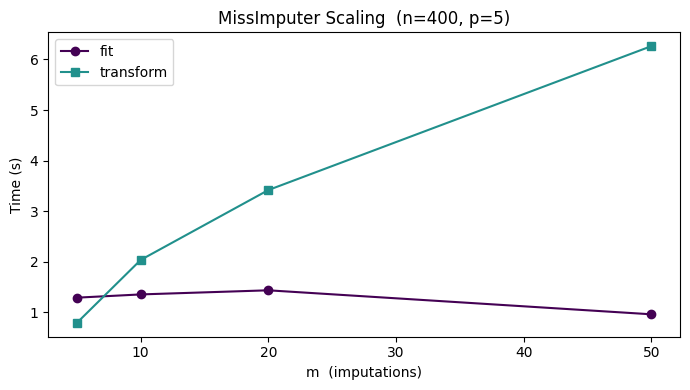

In [13]:
results_imp = bench_imputer_scaling(plot=True)

---
### 8. Cross-Validation Overhead (cv)
Total wall time for `miss_cross_val_score()` vs number of folds, expressed
as a multiple of a single fit.  Reveals per-fold overhead relative to naive
cv × fit_time expectation.

**Defaults:** `cv_values=[3, 5, 10]`, `n=400`, `p=5`, `miss=20%`, `repeats=2`


  Cross-Validation Overhead: Time vs cv
  n=400  p=5  miss=20%  repeats=2

  MissRidge (reg)  (single fit = 4.73 s)
  cv   total time   vs 1 fit
  --   ----------   --------
  3    21.58 s      4.6x    
  5    21.28 s      4.5x    
  10   58.51 s      12.4x   

  MissRidge (clf)  (single fit = 27.61 s)
  cv   total time   vs 1 fit
  --   ----------   --------
  3    62.08 s      2.2x    
  5    124.72 s     4.5x    
  10   92.12 s      3.3x    


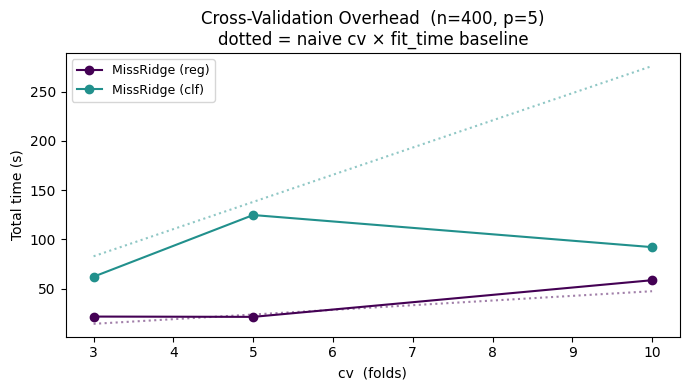

In [16]:
results_cv = bench_crossval_scaling(plot=True)

---
### 9. MissGaussian: O(n³) Scaling
Gaussian Process models require O(n³) Cholesky factorisation.  This
benchmark uses small `n` (≤ 150) to keep it tractable and confirm the
cubic growth empirically.

**Defaults:** `n_values=[10, 20, 30, 50, 75, 100, 125, 150]`, `p=3`, `miss=15%`, `repeats=2`


  MissGaussian Scaling: Fit Time vs n  (O(n³))
  p=3  miss=15%  repeats=2
  n     MissGaussian (reg)   MissGaussian (clf)
  ---   ------------------   ------------------
  10    368.9 ms             412.7 ms          
  20    308.9 ms             617.6 ms          
  30    274.8 ms             396.4 ms          
  50    315.2 ms             667.2 ms          
  75    512.3 ms             661.7 ms          
  100   604.0 ms             1.65 s            
  125   4.81 s               10.34 s           
  150   16.56 s              14.57 s           


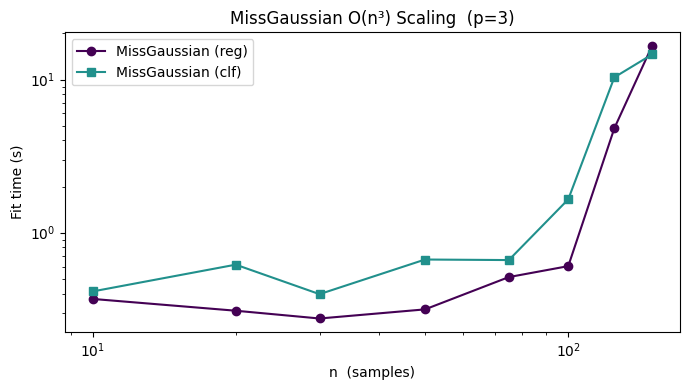

In [19]:
results_gp = bench_gaussian_process(plot=True)

---
### 10. MissMixed: n_groups Scaling
Mixed-effects FIML fit time vs number of random-effect groups.  Total
sample size = `n_groups × obs_per_group`.

**Defaults:** `n_groups_values=[5, 10, 20, 40]`, `obs_per_group=8`, `p=4`, `repeats=1`


  MissMixed Scaling: Fit Time vs n_groups
  obs_per_group=8  p=4  miss=20%  repeats=1
  n_groups   n_total   MissMixed (reg)   MissMixed (clf)
  --------   -------   ---------------   ---------------
  5          40        14.19 s           18.91 s        
  10         80        21.03 s           34.23 s        
  20         160       19.70 s           34.06 s        
  40         320       30.43 s           54.68 s        


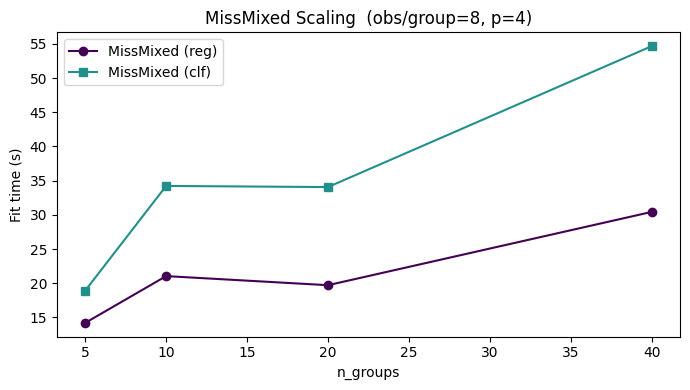

In [21]:
results_mixed = bench_mixed_effects(plot=True)

---
### 11. MissSensitivity: Delta-Grid Scaling
Sensitivity analysis re-fits the FIML model at each delta value, so
total time should grow linearly with `n_delta`.

**Defaults:** `n_delta_values=[5, 10, 20, 40, 80]`, `n=300`, `p=4`, `miss=20%`, `repeats=2`


  MissSensitivity Scaling: Fit Time vs n_delta
  n=300  p=4  miss=20%  repeats=2
  n_delta   fit time   time / delta  
  -------   --------   --------------
  5         8.46 s     1.69 s/delta  
  10        8.72 s     872.5 ms/delta
  20        24.60 s    1.23 s/delta  
  40        127.69 s   3.19 s/delta  
  80        176.38 s   2.20 s/delta  


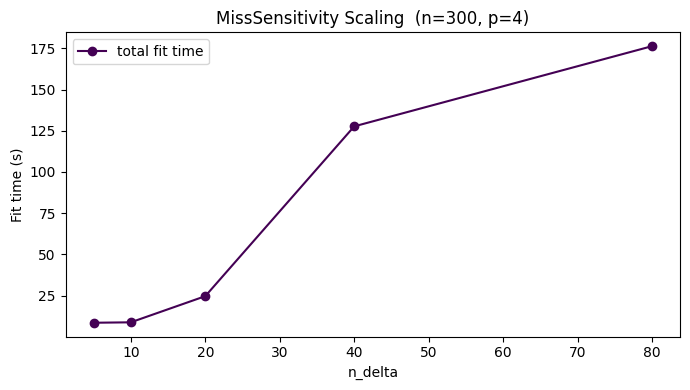

In [23]:
results_sens = bench_sensitivity(plot=True)

---
### Run All Benchmarks
Executes every function sequentially with default parameters (no plots).  
Expect 15 to 30 minutes depending on hardware.

In [ ]:
import time as _t
t0 = _t.perf_counter()

bench_model_comparison(plot=True)
bench_n_scaling(plot=True)
bench_p_scaling(plot=True)
bench_missingness_impact(plot=True)
bench_ensemble_scaling(plot=True)
bench_shapley_scaling(plot=True)
bench_imputer_scaling(plot=True)
bench_crossval_scaling(plot=True)
bench_gaussian_process(plot=True)
bench_mixed_effects(plot=True)
bench_sensitivity(plot=True)

elapsed = _t.perf_counter() - t0
print(f"\nAll benchmarks complete in {elapsed/60:.1f} min ({elapsed:.0f} s)")